In [2]:
import numpy as np
from IPython.core.history import extract_hist_ranges
from numpy.linalg import inv
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import PolynomialFeatures

## Question 2

In [4]:
X = np.array([[-10],[-8],[-3],[-1],[2],[8]])
y = np.array([[5],[5],[4],[3],[2],[2]])

poly = PolynomialFeatures(degree = 3 )
P = poly.fit_transform(X)
print(P)

w_poly = inv(P.T @ P)@ P.T @ y #Overdetermined system
print(w_poly)

X_biased = np.c_[np.ones((X.shape[0],1)),X]
w_linear = inv(X_biased.T @ X_biased)@X_biased.T @ y
print(w_linear)

X_test = np.array([[9]])
y_pred_poly = poly.transform(X_test) @ w_poly
print(y_pred_poly)
X_test = np.c_[np.ones((X_test.shape[0],1)),X_test]
y_pred_linear = X_test @ w_linear
print(y_pred_linear)

[[    1.   -10.   100. -1000.]
 [    1.    -8.    64.  -512.]
 [    1.    -3.     9.   -27.]
 [    1.    -1.     1.    -1.]
 [    1.     2.     4.     8.]
 [    1.     8.    64.   512.]]
[[ 2.68935636]
 [-0.37722517]
 [ 0.01343815]
 [ 0.00285772]]
[[ 3.10550459]
 [-0.19724771]]
[[2.46609771]]
[[1.33027523]]


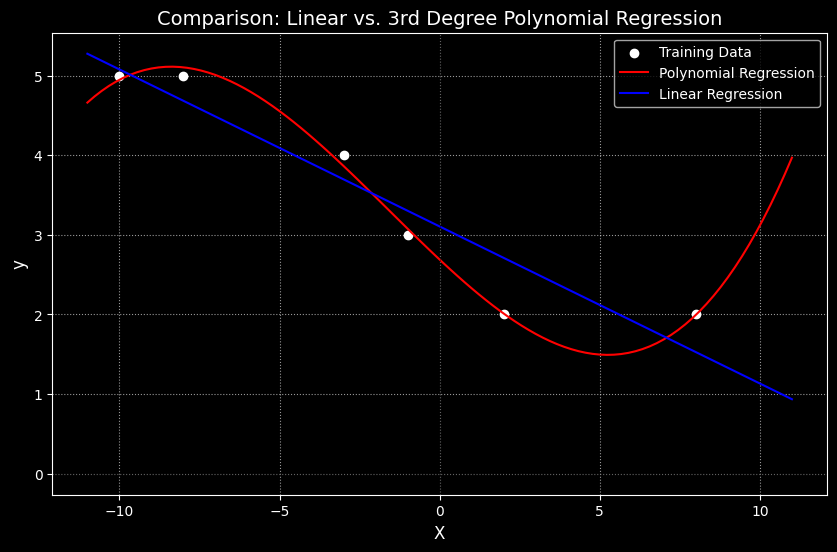

In [5]:
x_range = np.linspace(-11,11,100).reshape(-1,1)
P_range = poly.transform(x_range)
y_range_poly = P_range @ w_poly

X_range_biased = np.c_[np.ones((x_range.shape[0],1)),x_range]
y_range_linear = X_range_biased @ w_linear


plt.figure(figsize=(10,6))
plt.scatter(X,y,color='white',label='Training Data')
plt.plot(x_range, y_range_poly,color='red',label='Polynomial Regression')
plt.plot(x_range, y_range_linear, color = 'blue', label = 'Linear Regression')

plt.title("Comparison: Linear vs. 3rd Degree Polynomial Regression", fontsize=14)
plt.xlabel("X", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.axhline(0, color='black', linewidth=0.5, alpha=0.5)
plt.axvline(0, color='black', linewidth=0.5, alpha=0.5)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

## Question 3

In [6]:
X = np.array([[1,0,1],[1,-1,1]])
y = np.array([[0],[1]])

poly = PolynomialFeatures(degree = 3)
P = poly.fit_transform(X)
print("P:\n",P)

w_dual = P.T @ inv(P @ P.T) @ y #underdetermined (dual form)
print("w_dual\n:",w_dual)

lamda =  0.0001
I = np.eye(P.shape[1])
w_primal = inv(P.T @ P + lamda*I) @ P.T @ y #Overdetrmined (primal form)
print("w_primal:\n",w_primal)




P:
 [[ 1.  1.  0.  1.  1.  0.  1.  0.  0.  1.  1.  0.  1.  0.  0.  1.  0.  0.
   0.  1.]
 [ 1.  1. -1.  1.  1. -1.  1.  1. -1.  1.  1. -1.  1.  1. -1.  1. -1.  1.
  -1.  1.]]
w_dual
: [[ 0. ]
 [ 0. ]
 [-0.1]
 [ 0. ]
 [ 0. ]
 [-0.1]
 [ 0. ]
 [ 0.1]
 [-0.1]
 [ 0. ]
 [ 0. ]
 [-0.1]
 [ 0. ]
 [ 0.1]
 [-0.1]
 [ 0. ]
 [-0.1]
 [ 0.1]
 [-0.1]
 [ 0. ]]
w_primal:
 [[ 9.99973963e-07]
 [ 9.99967597e-07]
 [-9.99980000e-02]
 [ 9.99974532e-07]
 [ 9.99971803e-07]
 [-9.99980000e-02]
 [ 9.99968279e-07]
 [ 9.99980001e-02]
 [-9.99980001e-02]
 [ 9.99970325e-07]
 [ 9.99969984e-07]
 [-9.99980000e-02]
 [ 9.99967597e-07]
 [ 9.99980001e-02]
 [-9.99980001e-02]
 [ 9.99971007e-07]
 [-9.99980001e-02]
 [ 9.99980000e-02]
 [-9.99980000e-02]
 [ 9.99969416e-07]]


Note:
* At $\lambda = 0.0001$, we observe a close solution to that in (c) even though (d) constitutes an **approximation** whereas (c) is exact

## Question 4 : Binary Classification

In [7]:
X = np.array([[-1],[0],[0.5],[0.3],[0.8]])
#Take class1 as +1 , class 2 as -1
y = np.array([[1],[1],[-1],[1],[-1]])

X = np.c_[np.ones((X.shape[0],1)),X] #Remember to add bias
w = inv(X.T @ X) @ X.T @ y #Overdetermined-system

print("w:\n",w)

X_test = np.array([[-0.1],[0.4]])
X_test = np.c_[np.ones((X_test.shape[0],1)),X_test]

y = np.sign(X_test @ w)
print("y:\n", y)

w:
 [[ 0.33333333]
 [-1.11111111]]
y:
 [[ 1.]
 [-1.]]


## Question 5

In [4]:
X = np.array([[-1],[0],[0.5],[0.3],[0.8]])
y = np.array([[1],[1],[2],[3],[2]])

X_test = np.array([[-0.1],[0.4]])

#Transform to one-hot encoded y
one_hot_encoder = OneHotEncoder(sparse_output=False)
y_one_hot = one_hot_encoder.fit_transform(y)

#Linear regression model
X_linear = np.c_[np.ones((X.shape[0],1)),X]
w_linear = inv(X_linear.T @ X_linear) @ X_linear.T @ y_one_hot #Over-determined system
y_pred_linear = np.c_[np.ones((X_test.shape[0],1)),X_test] @ w_linear
y_pred_class = [[1 if y == max(x) else 0 for y in x] for x in y_pred_linear] #iterate each row and get the max col
print("Raw scores:\n", y_pred_linear)
print("Predicted Class Indices:\n", y_pred_class)

#Polynomial regression model of order 5
poly = PolynomialFeatures(degree = 5)
P = poly.fit_transform(X)

w_poly = P.T @ inv(P @ P.T) @ y_one_hot #under-determined system
y_pred_poly = poly.transform(X_test) @ w_poly
y_pred_class = [[1 if y == max(x) else 0 for y in x] for x in y_pred_poly]
print("Raw scores:\n", y_pred_poly)
print("Predicted Class:\n", y_pred_class)


Raw scores:
 [[0.54297694 0.27777778 0.17924528]
 [0.21802935 0.55555556 0.22641509]]
Predicted Class Indices:
 [[1, 0, 0], [0, 1, 0]]
Raw scores:
 [[ 1.57522369  0.46828063 -1.04350432]
 [-0.05207932  0.45436978  0.59770954]]
Predicted Class:
 [[1, 0, 0], [0, 0, 1]]


## Question 6

In [6]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

In [7]:
#Split database into training and testing
iris_dataset = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_dataset['data'], iris_dataset['target'], test_size = 0.26, random_state = 0)
print(X_train)
print(y_train)

[[5.8 2.6 4.  1.2]
 [6.8 3.  5.5 2.1]
 [4.7 3.2 1.3 0.2]
 [6.9 3.1 5.1 2.3]
 [5.  3.5 1.6 0.6]
 [5.4 3.7 1.5 0.2]
 [5.  2.  3.5 1. ]
 [6.5 3.  5.5 1.8]
 [6.7 3.3 5.7 2.5]
 [6.  2.2 5.  1.5]
 [6.7 2.5 5.8 1.8]
 [5.6 2.5 3.9 1.1]
 [7.7 3.  6.1 2.3]
 [6.3 3.3 4.7 1.6]
 [5.5 2.4 3.8 1.1]
 [6.3 2.7 4.9 1.8]
 [6.3 2.8 5.1 1.5]
 [4.9 2.5 4.5 1.7]
 [6.3 2.5 5.  1.9]
 [7.  3.2 4.7 1.4]
 [6.5 3.  5.2 2. ]
 [6.  3.4 4.5 1.6]
 [4.8 3.1 1.6 0.2]
 [5.8 2.7 5.1 1.9]
 [5.6 2.7 4.2 1.3]
 [5.6 2.9 3.6 1.3]
 [5.5 2.5 4.  1.3]
 [6.1 3.  4.6 1.4]
 [7.2 3.2 6.  1.8]
 [5.3 3.7 1.5 0.2]
 [4.3 3.  1.1 0.1]
 [6.4 2.7 5.3 1.9]
 [5.7 3.  4.2 1.2]
 [5.4 3.4 1.7 0.2]
 [5.7 4.4 1.5 0.4]
 [6.9 3.1 4.9 1.5]
 [4.6 3.1 1.5 0.2]
 [5.9 3.  5.1 1.8]
 [5.1 2.5 3.  1.1]
 [4.6 3.4 1.4 0.3]
 [6.2 2.2 4.5 1.5]
 [7.2 3.6 6.1 2.5]
 [5.7 2.9 4.2 1.3]
 [4.8 3.  1.4 0.1]
 [7.1 3.  5.9 2.1]
 [6.9 3.2 5.7 2.3]
 [6.5 3.  5.8 2.2]
 [6.4 2.8 5.6 2.1]
 [5.1 3.8 1.6 0.2]
 [4.8 3.4 1.6 0.2]
 [6.5 3.2 5.1 2. ]
 [6.7 3.3 5.7 2.1]
 [4.5 2.3 1.

In [8]:
#One hot encoding
one_hot_encoder = OneHotEncoder(sparse_output=False)
reshaped = y_train.reshape(len(y_train),1)
print(reshaped)
Ytr_one_hot = one_hot_encoder.fit_transform(reshaped)
reshaped = y_test.reshape(len(y_test),1)
Yts_one_hot = one_hot_encoder.transform(reshaped)
print(Ytr_one_hot)

[[1]
 [2]
 [0]
 [2]
 [0]
 [0]
 [1]
 [2]
 [2]
 [2]
 [2]
 [1]
 [2]
 [1]
 [1]
 [2]
 [2]
 [2]
 [2]
 [1]
 [2]
 [1]
 [0]
 [2]
 [1]
 [1]
 [1]
 [1]
 [2]
 [0]
 [0]
 [2]
 [1]
 [0]
 [0]
 [1]
 [0]
 [2]
 [1]
 [0]
 [1]
 [2]
 [1]
 [0]
 [2]
 [2]
 [2]
 [2]
 [0]
 [0]
 [2]
 [2]
 [0]
 [2]
 [0]
 [2]
 [2]
 [0]
 [0]
 [2]
 [0]
 [0]
 [0]
 [1]
 [2]
 [2]
 [0]
 [0]
 [0]
 [1]
 [1]
 [0]
 [0]
 [1]
 [0]
 [2]
 [1]
 [2]
 [1]
 [0]
 [2]
 [0]
 [2]
 [0]
 [0]
 [2]
 [0]
 [2]
 [1]
 [1]
 [1]
 [2]
 [2]
 [1]
 [1]
 [0]
 [1]
 [2]
 [2]
 [0]
 [1]
 [1]
 [1]
 [1]
 [0]
 [0]
 [0]
 [2]
 [1]
 [2]
 [0]]
[[0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [1. 0. 0.]


In [ ]:
#Perform linear regression
X_train_b = np.c_[np.ones((X_train.shape[0],1)), X_train]
X_test_b = np.c_[np.ones((X_test.shape[0],1)), X_test]

print(X_train_b)
w = inv(X_train_b.T @ X_train_b) @ X_train_b.T @ Ytr_one_hot
print(w)

yt_est = X_test_b @ w
yt_cls = [[1 if y == max(x) else 0 for y in x] for x in yt_est]
print(yt_cls)


In [ ]:
#compare trained output with real output
m1 = np.matrix(Yts_one_hot)
m2 = np.matrix(yt_cls)

diff = np.abs(m1-m2)
print(diff)
correct = np.where(~diff.any(axis=1))[0] #indices of correct flower classification
accuracy = len(correct)/len(diff)
print(len(correct))
print(accuracy)

In [ ]:
#Polynomial Classification
poly = PolynomialFeatures(degree = 2)
P = poly.fit_transform(X_train)
Pt = poly.transform(X_test)
if P.shape[0] > P.shape[1]: #more rows than col (m > d)
    wp = inv(P.T @ P) @ P.T @ Ytr_one_hot #Overdetermined
else:
    wp = P.T @ inv(P @ P.T) @ Ytr_one_hot #Underdetermined
print(wp)

yt_est_p = Pt @ wp
yt_cls_p = [[1 if y == max(x) else 0 for y in x] for x in yt_est_p]
print(yt_cls_p)

In [ ]:
#Evaluate the model
m1 = np.matrix(Yts_one_hot)
m2 = np.matrix(yt_cls_p)

diff = np.abs(m1 - m2)
correct_p = np.where(~diff.any(axis=1))[0]
accuracy_p = len(correct_p)/len(diff)
print(correct_p)
print(accuracy_p)